# U-Net Reconstruction Baseline

## Introduction


This project investigates the generation of furniture photographs from Canny edge sketches using paired image-to-image learning. The previous notebook produced 14318 usable 256 × 256 sketch-photo pairs while preserving the original training, validation, and test splits.

This notebook implements a reconstruction-only U-Net trained with L1 loss, without a discriminator or adversarial training. It establishes a baseline for how much structural and appearance information can be reconstructed directly from the edge maps. Next Notebook 04 will reuse the same U-Net architecture within Pix2Pix, allowing the effect of adversarial training to be evaluated separately.

The notebook covers the Colab environment and data loading, dataset verification, U-Net implementation, checkpointed pilot and full training, and evaluation of reconstructed validation images.

## Setup and Environment

Google Colab provides the execution environment for model training. The prepared dataset archive is stored in Google Drive and extracted to the Colab local disk for faster image loading. Model checkpoints remain in Google Drive so training can be resumed after a runtime disconnection.

In [4]:
# Imports, Random Seeds, and Runtime Check

from pathlib import Path
import random
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.functional as TF

from tqdm.auto import tqdm
import time

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Fixed 256 × 256 inputs allow cuDNN to select faster algorithms.
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not enabled.")

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Device: cuda
GPU: Tesla T4


The prepared dataset archive is stored in Google Drive and extracted to the Colab local disk for faster image loading. Model checkpoints remain in Google Drive so training can be resumed after a runtime disconnection.

To reproduce this setup, the prepared archive must be placed inside the `colab_data` directory. Normally, only `DRIVE_ROOT` needs to be changed.

In [39]:
# Google Drive and Environment-Dependent Paths

from google.colab import drive

drive.mount("/content/drive")

# The only path that should normally needs to change
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Sketch2Furniture"
)

ARCHIVE_PATH = (
    DRIVE_ROOT / "colab_data" / "paired_dataset.tar"
)

CKPT_DIR = (
    DRIVE_ROOT / "checkpoints" / "unet_baseline"
)

LOCAL_ROOT = Path("/content")

PAIRED_DATA_DIR = (
    LOCAL_ROOT / "data" / "processed" / "paired"
)

PREPARED_METADATA_PATH = (
    PAIRED_DATA_DIR / "prepared_metadata.csv"
)

EXTRACTION_MARKER = (
    PAIRED_DATA_DIR / ".extraction_complete"
)

if not DRIVE_ROOT.is_dir():
    raise FileNotFoundError(
        f"Drive project folder not found: {DRIVE_ROOT}"
    )

if not ARCHIVE_PATH.is_file():
    raise FileNotFoundError(
        f"Prepared dataset archive not found: {ARCHIVE_PATH}"
    )

CKPT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LATEST_CHECKPOINT_PATH = CKPT_DIR / "latest_checkpoint.pt"
BEST_GENERATOR_PATH = CKPT_DIR / "best_generator.pt"

FIGURE_DIR = DRIVE_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

archive_size_gib = ARCHIVE_PATH.stat().st_size / (1024 ** 3)

print(f"Drive root: {DRIVE_ROOT}")
print(f"Archive path: {ARCHIVE_PATH}")
print(f"Archive size: {archive_size_gib:.2f} GiB")
print(f"Checkpoint directory: {CKPT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/MyDrive/Sketch2Furniture
Archive path: /content/drive/MyDrive/Sketch2Furniture/colab_data/paired_dataset.tar
Archive size: 1.02 GiB
Checkpoint directory: /content/drive/MyDrive/Sketch2Furniture/checkpoints/unet_baseline


In [6]:
# Verify the Uploaded Archive

checksum_result = subprocess.run(
    ["sha256sum", str(ARCHIVE_PATH)],
    capture_output=True,
    text=True,
    check=True,
)

archive_checksum = checksum_result.stdout.split()[0]

print(f"Archive SHA256: {archive_checksum}")

Archive SHA256: 91c2d6fa631af7df728318847d0cd9f0d79b8c5006e8ae5deb65208f34460dd2


The prepared image pairs are stored in Google Drive as a single archive for convenient transfer between Colab sessions. After verifying its checksum, the archive is extracted to Colab's temporary local storage, where loading thousands of individual images is faster than reading them through the mounted Drive.

A marker file is created after successful extraction, allowing the cell to be re-run without repeating the work during the same runtime. Because Colab local storage is temporary, the extraction is performed again when a new runtime starts.

In [7]:
# Extract the Prepared Dataset to Colab Local Storage

extraction_ready = (
    EXTRACTION_MARKER.is_file()
    and PREPARED_METADATA_PATH.is_file()
)

if not extraction_ready:
    print("Extracting the prepared dataset...")

    subprocess.run(
        [
            "tar",
            "-xf",
            str(ARCHIVE_PATH),
            "-C",
            str(LOCAL_ROOT),
        ],
        check=True,
    )

    if not PREPARED_METADATA_PATH.is_file():
        raise FileNotFoundError(
            "Extraction completed, but prepared_metadata.csv "
            "was not found."
        )

    EXTRACTION_MARKER.touch()
    print("Dataset extracted successfully.")
else:
    print("Prepared dataset is already extracted.")

png_count = sum(
    1 for _ in PAIRED_DATA_DIR.rglob("*.png")
)

print(f"PNG files extracted: {png_count}")
print(f"Metadata path: {PREPARED_METADATA_PATH}")

Extracting the prepared dataset...
Dataset extracted successfully.
PNG files extracted: 28668
Metadata path: /content/data/processed/paired/prepared_metadata.csv


### Observation

The extraction restored 28668 PNG files, representing all 14334 generated edge-photo pairs. This total includes the 16 pairs whose edge maps were completely blank. Those pairs were excluded from `prepared_metadata.csv` during data preparation, although their files were retained in the directory structure.

The metadata file therefore defines the 14318 usable pairs for training and evaluation; a directory scan does not.

## Loading the Prepared Metadata

The prepared metadata serves as the authoritative manifest for training and evaluation. It preserves the original dataset splits and excludes the 16 blank image pairs identified during data preparation. Although those files remain in the extracted folders, they are not loaded by the datasets.

In [8]:
# Load the Prepared Metadata

prepared_metadata = pd.read_csv(
    PREPARED_METADATA_PATH
)

print(f"Metadata rows: {len(prepared_metadata)}")
print(f"Metadata columns: {prepared_metadata.shape[1]}")

preview_columns = [
    "pair_id",
    "split",
    "category",
    "style",
    "width",
    "height",
    "generation_success",
]

metadata_preview = (
    prepared_metadata[preview_columns]
    .head()
    .rename(
        columns={
            "width": "source_width",
            "height": "source_height",
        }
    )
)

display(metadata_preview)

Metadata rows: 14318
Metadata columns: 30


,pair_id,split,category,style,source_width,source_height,generation_success
0,pair_00001,train,beds,Asian,350,350,True
1,pair_00002,train,beds,Asian,350,350,True
2,pair_00003,train,beds,Asian,350,350,True
3,pair_00004,train,beds,Asian,350,350,True
4,pair_00005,validation,beds,Asian,350,350,True


### Observation

The prepared metadata contains 14318 usable pairs and preserves their original dataset splits, categories, and styles.

The `source_width` and `source_height` columns shown in the preview describe the original images inspected in Notebook 01. They were renamed in the preview to distinguish them from the prepared edge-photo pairs, which were resized to 256 × 256 during data preparation. The dimensions of the generated files will be verified directly before constructing the datasets.

In [9]:
# Inspect the Dataset Split Counts

split_summary = (
    prepared_metadata["split"]
    .value_counts(sort=False)
    .rename_axis("split")
    .reset_index(name="pair_count")
)

split_summary["percentage"] = (
    split_summary["pair_count"]
    .div(len(prepared_metadata))
    .mul(100)
    .round(2)
)

display(split_summary)

print(f"Total usable pairs: {split_summary['pair_count'].sum()}")

,split,pair_count,percentage
0,train,9718,67.87
1,validation,1708,11.93
2,test,2892,20.20


Total usable pairs: 14318


### Observation

The metadata preserves the original dataset split distribution: 9718 pairs belong to the training set, 1708 to validation, and 2892 to testing. Together, they account for all 14318 usable pairs.

Keeping these predefined splits avoids reshuffling related images across subsets and maintains consistency with the earlier stages of the project.

The stored `input_path` and `target_path` values refer to the local environment used during data preparation. For Colab, only the path prefix is replaced; each file's split, subdirectory, and filename remain unchanged. The original `source_path` is not rebuilt because the source images are not required for training.

In [10]:
# Rebuild the Prepared Image Paths for Colab

def rebuild_colab_path(stored_path):
    stored_path = Path(stored_path)
    path_parts = stored_path.parts

    if "paired" not in path_parts:
        raise ValueError(
            f"'paired' directory not found in path: {stored_path}"
        )

    paired_index = path_parts.index("paired")
    relative_path = Path(
        *path_parts[paired_index + 1:]
    )

    return PAIRED_DATA_DIR / relative_path


for column in ("input_path", "target_path"):
    prepared_metadata[column] = (
        prepared_metadata[column]
        .map(rebuild_colab_path)
    )

    missing_count = (
        prepared_metadata[column]
        .map(lambda path: not path.is_file())
        .sum()
    )

    print(f"Missing {column} files: {missing_count}")
    print(f"Example {column}: {prepared_metadata[column].iloc[0]}")

Missing input_path files: 0
Example input_path: /content/data/processed/paired/train/A/pair_00001.png
Missing target_path files: 0
Example target_path: /content/data/processed/paired/train/B/pair_00001.png


### Observation

The input and target paths were successfully rebuilt for the Colab environment. No referenced files are missing, confirming that all 14318 usable pairs are available after extraction.

Before constructing the PyTorch datasets, the generated files are inspected directly to confirm their actual dimensions and color modes. This verifies the prepared training representation without relying on the original source-image dimensions retained in the metadata.

In [11]:
from collections import Counter

def collect_image_properties(paths):
    sizes = Counter()
    modes = Counter()
    for path in paths:
        with Image.open(path) as image:
            sizes[image.size] += 1
            modes[image.mode] += 1
    return sizes, modes

for column in ("input_path", "target_path"):
    sizes, modes = collect_image_properties(
        prepared_metadata[column]
    )

    print(f"{column} sizes: {sizes.most_common()}")
    print(f"{column} modes: {modes.most_common()}")

input_path sizes: [((256, 256), 14318)]
input_path modes: [('L', 14318)]
target_path sizes: [((256, 256), 14318)]
target_path modes: [('RGB', 14318)]


### Observation

All 14318 usable input images measure 256 × 256 and use mode `L` (single-channel grayscale), while all corresponding targets measure 256 × 256 and use mode `RGB` (three-channel color). No deviations were found.

Together with the matching archive checksum and the absence of missing referenced files, these results confirm that the prepared dataset was transferred and extracted successfully and that its representation matches the specification established in Notebook 02.

## Dataset and Data Loaders

This section constructs the PyTorch input pipeline for the prepared edge-photo pairs. A custom dataset class will load each grayscale edge map with its corresponding RGB target, normalize both images to the range `[-1, 1]`, and preserve the pair identifier for traceability. Separate datasets and data loaders will then be created for the predefined training, validation, and test splits.

Data augmentation is deliberately limited to a random horizontal flip with a probability of 0.5, applied only to training pairs. The input and target are flipped together to preserve their exact spatial correspondence. Horizontal flipping provides a plausible alternative view of furniture without changing its structure, while vertical flips and large rotations would create unrealistic orientations, and random crops could remove important parts of an object. Validation and test pairs remain unchanged to ensure deterministic and comparable evaluation.

In [12]:
# Define the Paired Furniture Dataset

class PairedFurnitureDataset(Dataset):
    def __init__(self, metadata, augment=False):
        self.metadata = (
            metadata
            .reset_index(drop=True)
            .copy()
        )
        self.augment = augment

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, index):
        row = self.metadata.iloc[index]

        with Image.open(row["input_path"]) as image:
            input_image = image.convert("L")

        with Image.open(row["target_path"]) as image:
            target_image = image.convert("RGB")

        if self.augment and torch.rand(1).item() < 0.5:
            input_image = TF.hflip(input_image)
            target_image = TF.hflip(target_image)

        input_tensor = (
            TF.to_tensor(input_image)
            .mul(2)
            .sub(1)
        )
        target_tensor = (
            TF.to_tensor(target_image)
            .mul(2)
            .sub(1)
        )

        return {
            "input": input_tensor,
            "target": target_tensor,
            "pair_id": row["pair_id"],
        }

In [13]:
# Create the Dataset Instances

train_dataset = PairedFurnitureDataset(
    prepared_metadata[
        prepared_metadata["split"] == "train"
    ],
    augment=True,
)

validation_dataset = PairedFurnitureDataset(
    prepared_metadata[
        prepared_metadata["split"] == "validation"
    ],
)

test_dataset = PairedFurnitureDataset(
    prepared_metadata[
        prepared_metadata["split"] == "test"
    ],
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(validation_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 9718
Validation samples: 1708
Test samples: 2892


In [14]:
# Inspect One Dataset Sample

sample = validation_dataset[0]

print(f"Sample keys: {list(sample.keys())}")
print(f"Pair ID: {sample['pair_id']}")

for name in ("input", "target"):
    tensor = sample[name]

    print(f"\n{name.capitalize()} shape: {tuple(tensor.shape)}")
    print(f"{name.capitalize()} dtype: {tensor.dtype}")
    print(
        f"{name.capitalize()} range: "
        f"[{tensor.min().item():.3f}, "
        f"{tensor.max().item():.3f}]"
    )

Sample keys: ['input', 'target', 'pair_id']
Pair ID: pair_00005

Input shape: (1, 256, 256)
Input dtype: torch.float32
Input range: [-1.000, 1.000]

Target shape: (3, 256, 256)
Target dtype: torch.float32
Target range: [-1.000, 1.000]


In [15]:
# Reverse the Image Normalization for Visualization

def denormalize(tensor):
    """Map image tensor values from [-1, 1] back to [0, 1]."""
    return tensor.add(1).div(2)

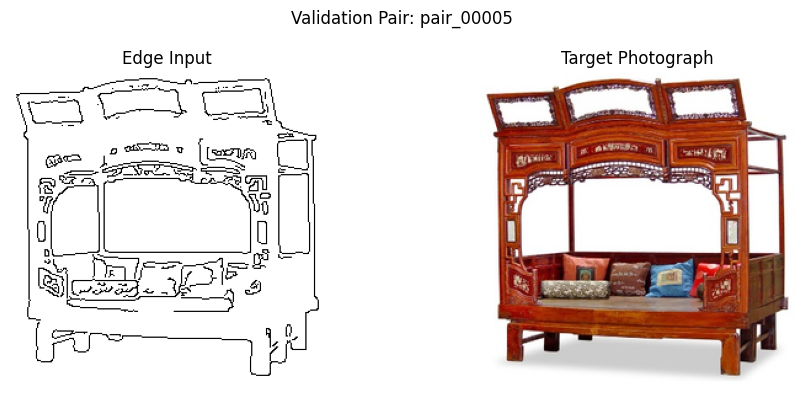

In [16]:
# Visualize One Dataset Sample

input_image = (
    denormalize(sample["input"])
    .squeeze(0)
    .numpy()
)

target_image = (
    denormalize(sample["target"])
    .permute(1, 2, 0)
    .numpy()
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(
    input_image,
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[0].set_title("Edge Input")

axes[1].imshow(target_image)
axes[1].set_title("Target Photograph")

for axis in axes:
    axis.axis("off")

fig.suptitle(f"Validation Pair: {sample['pair_id']}")
plt.tight_layout()
plt.show()

### Observation

The inspected validation sample has the expected tensor structure: a single-channel edge input and a three-channel RGB target, both represented as `float32` tensors with spatial dimensions of 256 × 256 and values normalized to `[-1, 1]`. The pair identifier is also retained for traceability.

After reversing the normalization for visualization, the input and target remain spatially aligned and clearly represent the same furniture instance. This confirms that the dataset class loads and transforms a prepared pair correctly without disrupting its correspondence.

In [17]:
# Create the Data Loaders

BATCH_SIZE = 8
NUM_WORKERS = 2

loader_settings = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": NUM_WORKERS > 0,
    "drop_last": False,
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_settings,
)

validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_settings,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_settings,
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(validation_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Pinned memory: {loader_settings['pin_memory']}")

Batch size: 8
Training batches: 1215
Validation batches: 214
Test batches: 362
Pinned memory: True


In [18]:
# Inspect One Data Loader Batch

batch = next(iter(validation_loader))

print(f"Batch keys: {list(batch.keys())}")
print(f"Samples in batch: {len(batch['pair_id'])}")
print(f"First pair ID: {batch['pair_id'][0]}")

for name in ("input", "target"):
    tensor = batch[name]

    print(f"\n{name.capitalize()} shape: {tuple(tensor.shape)}")
    print(f"{name.capitalize()} dtype: {tensor.dtype}")
    print(
        f"{name.capitalize()} range: "
        f"[{tensor.min().item():.3f}, "
        f"{tensor.max().item():.3f}]"
    )

Batch keys: ['input', 'target', 'pair_id']
Samples in batch: 8
First pair ID: pair_00005

Input shape: (8, 1, 256, 256)
Input dtype: torch.float32
Input range: [-1.000, 1.000]

Target shape: (8, 3, 256, 256)
Target dtype: torch.float32
Target range: [-1.000, 1.000]


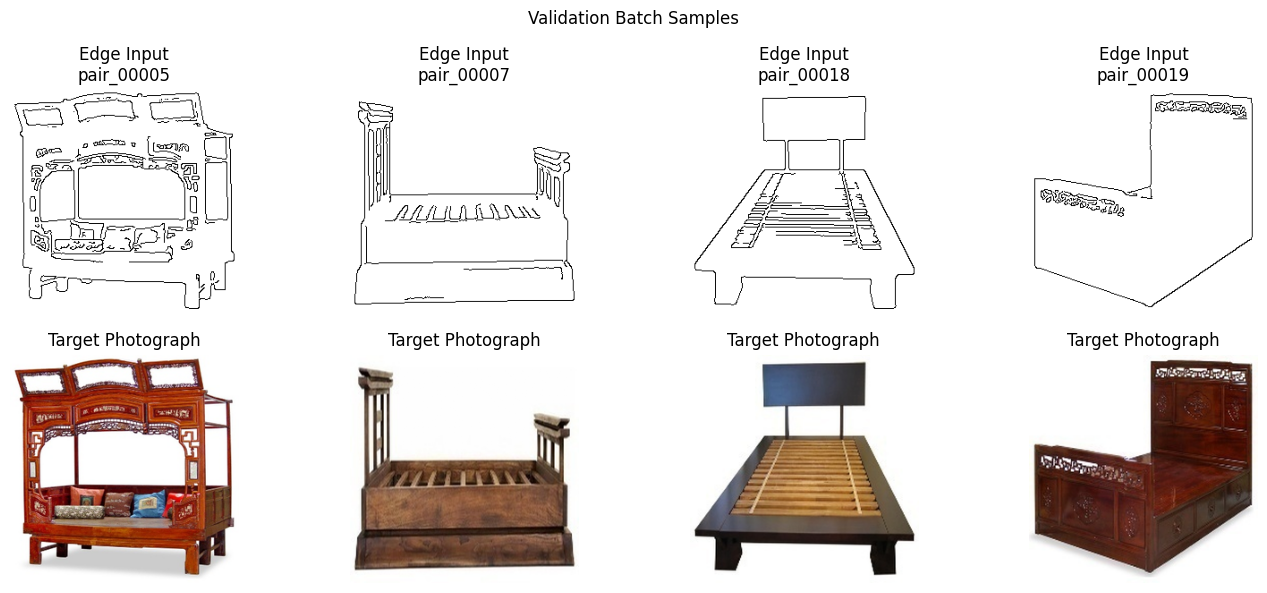

In [19]:
# Visualize Data Loader Batch Samples

num_display_pairs = 4

fig, axes = plt.subplots(2, num_display_pairs, figsize=(14, 6),)

for index in range(num_display_pairs):
    input_image = (
        denormalize(batch["input"][index])
        .squeeze(0)
        .numpy()
    )

    target_image = (
        denormalize(batch["target"][index])
        .permute(1, 2, 0)
        .numpy()
    )

    axes[0, index].imshow(
        input_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[0, index].set_title(
        f"Edge Input\n{batch['pair_id'][index]}"
    )

    axes[1, index].imshow(target_image)
    axes[1, index].set_title("Target Photograph")

for axis in axes.ravel():
    axis.axis("off")

fig.suptitle("Validation Batch Samples")
plt.tight_layout()
plt.show()

### Observation

With a batch size of 8, the training, validation, and test data loaders contain 1215, 214, and 362 batches, respectively. Training samples are shuffled, while validation and test ordering remains fixed. Incomplete final batches are retained so that every available pair is used.

The inspected validation batch has the expected shapes of `(8, 1, 256, 256)` for edge inputs and `(8, 3, 256, 256)` for target photographs. Both tensors use the `float32` data type and remain normalized to `[-1, 1]`.

The four visualized pairs are distinct, and each edge map corresponds spatially to its target photograph. All four examples are beds because the validation loader follows the fixed, category-grouped metadata ordering, placing samples from the same category in its early batches; this does not imply that the dataset contains only beds. The visualization confirms that the data loader preserves the pairing and tensor representation established by the dataset class.

## U-Net Model Architecture

This section defines the U-Net used as the reconstruction-only baseline. The model receives a single-channel edge map and generates a three-channel RGB image. Its encoder progressively extracts higher-level features, while the decoder restores the original spatial resolution. Skip connections transfer spatial details directly between corresponding encoder and decoder levels.

The output layer uses a `tanh` activation so that generated images match the `[-1, 1]` normalization applied to the targets. The same U-Net architecture will later be used as the Pix2Pix generator, allowing the effect of adversarial training to be compared against the L1-only baseline.

In [20]:
# Define the U-Net Building Blocks

class DownBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        normalize=True,
    ):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=not normalize,
            )
        ]

        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))

        layers.append(nn.LeakyReLU(0.2, inplace=True))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        dropout=False,
    ):
        super().__init__()

        layers = [
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]

        if dropout:
            layers.append(nn.Dropout(0.5))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [21]:
# Define the U-Net Generator

class UNetGenerator(nn.Module):
    def __init__(
        self,
        input_channels=1,
        output_channels=3,
    ):
        super().__init__()

        # Encoder
        self.down1 = DownBlock(
            input_channels, 64, normalize=False
        )
        self.down2 = DownBlock(64, 128)
        self.down3 = DownBlock(128, 256)
        self.down4 = DownBlock(256, 512)
        self.down5 = DownBlock(512, 512)
        self.down6 = DownBlock(512, 512)
        self.down7 = DownBlock(512, 512)
        self.down8 = DownBlock(
            512, 512, normalize=False
        )

        # Decoder
        self.up1 = UpBlock(512, 512, dropout=True)
        self.up2 = UpBlock(1024, 512, dropout=True)
        self.up3 = UpBlock(1024, 512, dropout=True)
        self.up4 = UpBlock(1024, 512)
        self.up5 = UpBlock(1024, 256)
        self.up6 = UpBlock(512, 128)
        self.up7 = UpBlock(256, 64)

        self.output = nn.Sequential(
            nn.ConvTranspose2d(
                128,
                output_channels,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.Tanh(),
        )

    def forward(self, x):
        # Encoder
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)

        # Decoder with skip connections
        u1 = torch.cat((self.up1(d8), d7), dim=1)
        u2 = torch.cat((self.up2(u1), d6), dim=1)
        u3 = torch.cat((self.up3(u2), d5), dim=1)
        u4 = torch.cat((self.up4(u3), d4), dim=1)
        u5 = torch.cat((self.up5(u4), d3), dim=1)
        u6 = torch.cat((self.up6(u5), d2), dim=1)
        u7 = torch.cat((self.up7(u6), d1), dim=1)

        return self.output(u7)

In [22]:
# Instantiate and Test the U-Net Generator

generator = UNetGenerator().to(DEVICE)
generator.eval()

validation_inputs = batch["input"].to(
    DEVICE,
    non_blocking=True,
)

with torch.no_grad():
    generated_batch = generator(validation_inputs)

parameter_count = sum(
    parameter.numel()
    for parameter in generator.parameters()
)

print(f"Generator device: {next(generator.parameters()).device}")
print(f"Input device: {validation_inputs.device}")
print(f"Output device: {generated_batch.device}")
print(f"Generator parameters: {parameter_count}")
print(f"Input shape: {tuple(validation_inputs.shape)}")
print(f"Output shape: {tuple(generated_batch.shape)}")
print(f"Output dtype: {generated_batch.dtype}")
print(f"Output range: [{generated_batch.min().item():.3f}, "
    f"{generated_batch.max().item():.3f}]")


Generator device: cuda:0
Input device: cuda:0
Output device: cuda:0
Generator parameters: 54412483
Input shape: (8, 1, 256, 256)
Output shape: (8, 3, 256, 256)
Output dtype: torch.float32
Output range: [-0.967, 0.963]


In [23]:
# Inspect the U-Net Feature-Map Shapes

feature_shapes = {}


def record_shape(name):
    def hook(module, inputs, output):
        feature_shapes[name] = tuple(output.shape)

    return hook


layer_names = [
    "down1", "down2", "down3", "down4",
    "down5", "down6", "down7", "down8",
    "up1", "up2", "up3", "up4",
    "up5", "up6", "up7", "output",
]

hooks = [
    getattr(generator, name).register_forward_hook(record_shape(name))
    for name in layer_names
]

inspection_input = batch["input"][:1].to(DEVICE, non_blocking=True,)

generator.eval()

try:
    with torch.no_grad():
        generator(inspection_input)
finally:
    for hook in hooks:
        hook.remove()

print(f"Inspection input device: {inspection_input.device}")

print("\nEncoder:")
for name in layer_names[:8]:
    print(f"{name}: {feature_shapes[name]}")

print("\nDecoder before skip concatenation:")
for name in layer_names[8:15]:
    print(f"{name}: {feature_shapes[name]}")

print(f"\nOutput: {feature_shapes['output']}")

Inspection input device: cuda:0

Encoder:
down1: (1, 64, 128, 128)
down2: (1, 128, 64, 64)
down3: (1, 256, 32, 32)
down4: (1, 512, 16, 16)
down5: (1, 512, 8, 8)
down6: (1, 512, 4, 4)
down7: (1, 512, 2, 2)
down8: (1, 512, 1, 1)

Decoder before skip concatenation:
up1: (1, 512, 2, 2)
up2: (1, 512, 4, 4)
up3: (1, 512, 8, 8)
up4: (1, 512, 16, 16)
up5: (1, 256, 32, 32)
up6: (1, 128, 64, 64)
up7: (1, 64, 128, 128)

Output: (1, 3, 256, 256)


### Observation

The U-Net generator contains 54412483 parameters and transforms single-channel 256 × 256 edge inputs into three-channel outputs with the same spatial dimensions. The model, input tensors, and generated outputs are placed on the selected device consistently.

The encoder progressively reduces the resolution from 256 × 256 to a 1 × 1 bottleneck, while the decoder restores it to 256 × 256. Before every skip concatenation, the decoder output has the same spatial dimensions as its corresponding encoder feature map, confirming that all skip connections are dimensionally compatible.

The final `tanh` layer keeps the generated values within `[-1, 1]`, matching the target normalization. These checks confirm the structural correctness of the architecture but do not evaluate reconstruction quality because the generator remains untrained.

In [24]:
# Initialize the U-Net Weights

def initialize_weights(module):
    """Initialize convolutional and batch-normalization layers."""
    if isinstance(
        module,
        (nn.Conv2d, nn.ConvTranspose2d),
    ):
        nn.init.normal_(
            module.weight,
            mean=0.0,
            std=0.02,
        )

        if module.bias is not None:
            nn.init.zeros_(module.bias)

    elif isinstance(module, nn.BatchNorm2d):
        nn.init.normal_(
            module.weight,
            mean=1.0,
            std=0.02,
        )
        nn.init.zeros_(module.bias)


generator.apply(initialize_weights)
generator.train()

first_conv = generator.down1.block[0]
first_batch_norm = generator.down2.block[1]

print(
    "Generator device: "
    f"{next(generator.parameters()).device}"
)
print(f"Training mode: {generator.training}")
print(
    "First convolution weights: "
    f"mean={first_conv.weight.mean().item():.4f}, "
    f"std={first_conv.weight.std().item():.4f}"
)
print(
    "First batch-normalization weights: "
    f"mean={first_batch_norm.weight.mean().item():.4f}, "
    f"std={first_batch_norm.weight.std().item():.4f}"
)

Generator device: cuda:0
Training mode: True
First convolution weights: mean=0.0005, std=0.0208
First batch-normalization weights: mean=1.0019, std=0.0174


In [25]:
# Configure and Verify the Reconstruction Loss and Optimizer

LEARNING_RATE = 0.0002
BETA_1 = 0.5
BETA_2 = 0.999

criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA_1, BETA_2),
)

optimizer_settings = optimizer.param_groups[0]
optimizer_parameter = optimizer_settings["params"][0]

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Optimizer parameter device: {optimizer_parameter.device}")
print(f"Learning rate: {optimizer_settings['lr']}")
print(f"Adam betas: {optimizer_settings['betas']}")

Loss function: L1Loss()
Optimizer: Adam
Optimizer parameter device: cuda:0
Learning rate: 0.0002
Adam betas: (0.5, 0.999)


In [26]:
# Verify One Device-Safe Optimization Step

training_batch = next(iter(train_loader))

training_inputs = training_batch["input"][:1].to(
    DEVICE,
    non_blocking=True,
)
training_targets = training_batch["target"][:1].to(
    DEVICE,
    non_blocking=True,
)

generator.train()
optimizer.zero_grad(set_to_none=True)

first_conv = generator.down1.block[0]
weights_before = first_conv.weight.detach().clone()

generated_images = generator(training_inputs)

training_loss = criterion(generated_images, training_targets,)

training_loss.backward()

gradient = first_conv.weight.grad
gradient_norm = gradient.norm().item()
gradients_finite = torch.isfinite(gradient).all().item()

optimizer.step()

maximum_weight_change = (
    first_conv.weight.detach() - weights_before
).abs().max().item()

optimizer_state = optimizer.state[first_conv.weight]

print(f"Generator device: {next(generator.parameters()).device}")
print(f"Input device: {training_inputs.device}")
print(f"Target device: {training_targets.device}")
print(f"Generated output device: {generated_images.device}")
print(f"Training mode: {generator.training}")
print(f"Training loss: {training_loss.item():.4f}")
print(f"Loss finite: {torch.isfinite(training_loss).item()}")
print(f"First-layer gradient norm: {gradient_norm:.6f}")
print(f"Gradients finite: {gradients_finite}")
print(f"First-layer parameters updated: {maximum_weight_change > 0}")
print(
    "Maximum first-layer weight change: "
    f"{maximum_weight_change:.8f}"
)
print(
    "Adam first-moment device: "
    f"{optimizer_state['exp_avg'].device}"
)
print(
    "Adam second-moment device: "
    f"{optimizer_state['exp_avg_sq'].device}"
)

Generator device: cuda:0
Input device: cuda:0
Target device: cuda:0
Generated output device: cuda:0
Training mode: True
Training loss: 0.6917
Loss finite: True
First-layer gradient norm: 0.235152
Gradients finite: True
First-layer parameters updated: True
Maximum first-layer weight change: 0.00020000
Adam first-moment device: cuda:0
Adam second-moment device: cuda:0


In [27]:
# Reset the Model and Optimizer After the Diagnostic Step

generator = UNetGenerator().to(DEVICE)
generator.apply(initialize_weights)
generator.train()

optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA_1, BETA_2),
)

gradients_cleared = all(
    parameter.grad is None
    for parameter in generator.parameters()
)

optimizer_parameter = optimizer.param_groups[0]["params"][0]

print(f"Generator device: {next(generator.parameters()).device}")
print(f"Optimizer parameter device: {optimizer_parameter.device}")
print(f"Training mode: {generator.training}")
print(f"Gradients cleared: {gradients_cleared}")
print(f"Optimizer state entries: {len(optimizer.state)}")

Generator device: cuda:0
Optimizer parameter device: cuda:0
Training mode: True
Gradients cleared: True
Optimizer state entries: 0


In [28]:
# Configure Mixed-Precision Training

USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.float16

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)

print(f"Selected device: {DEVICE}")
print(f"Mixed precision enabled: {scaler.is_enabled()}")
print(f"Autocast dtype: {AMP_DTYPE}")

Selected device: cuda
Mixed precision enabled: True
Autocast dtype: torch.float16


### Observation

The generator was initialized using the Pix2Pix weight-initialization scheme, moved to the selected device, and placed in training mode before constructing the optimizer. The measured weight statistics were consistent with the intended distributions. The baseline uses $L_1$ loss and Adam with a learning rate of 0.0002 and beta values of 0.5 and 0.999, with the first beta following the Pix2Pix convention so that the generator-optimizer settings remain aligned with Notebook 04 and the main experimental difference is the training objective.

One diagnostic step produced a finite loss of 0.7110, finite nonzero gradients, and an update to the generator parameters. All model, data, output, and optimizer-state tensors were located on the same device.

Mixed precision was configured with `float16`; it is disabled on the current CPU runtime and will activate on CUDA. After the diagnostic step, the generator and optimizer were recreated so that training begins from a clean state.

### Reusable Training and Validation Functions

The following functions perform one training or validation epoch. Both calculate the sample-weighted mean $L_1$ loss, since `drop_last=False` leaves a shorter final batch that would otherwise carry the same weight as a full one.
The training function also supports mixed-precision optimization when CUDA is selected.


In [29]:
# Define One Training Epoch

def train_one_epoch(
    model,
    data_loader,
    loss_function,
    optimizer,
    gradient_scaler,
    device,
    use_amp,
    amp_dtype,
):
    """Train the model for one epoch and return the mean loss."""
    model.train()

    loss_sum = torch.zeros(
        (),
        device=device,
    )
    sample_count = 0

    for batch_data in tqdm(data_loader, desc="Training", leave=False):
        inputs = batch_data["input"].to(
            device,
            non_blocking=True,
        )
        targets = batch_data["target"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=device.type,
            dtype=amp_dtype,
            enabled=use_amp,
        ):
            predictions = model(inputs)
            loss = loss_function(
                predictions,
                targets,
            )

        gradient_scaler.scale(loss).backward()
        gradient_scaler.step(optimizer)
        gradient_scaler.update()

        batch_size = inputs.size(0)
        loss_sum += loss.detach() * batch_size
        sample_count += batch_size

    if sample_count == 0:
        raise ValueError("The training data loader is empty.")

    mean_loss = (
        loss_sum / sample_count
    ).item()

    return mean_loss

In [30]:
# Define One Validation Epoch

def validate_one_epoch(
    model,
    data_loader,
    loss_function,
    device,
    use_amp,
    amp_dtype,
):
    """Evaluate the model for one epoch and return the mean loss."""
    model.eval()

    loss_sum = torch.zeros(
        (),
        device=device,
    )
    sample_count = 0

    with torch.no_grad():
        for batch_data in tqdm(
            data_loader,
            desc="Validation",
            leave=False,
        ):
            inputs = batch_data["input"].to(
                device,
                non_blocking=True,
            )
            targets = batch_data["target"].to(
                device,
                non_blocking=True,
            )

            with torch.autocast(
                device_type=device.type,
                dtype=amp_dtype,
                enabled=use_amp,
            ):
                predictions = model(inputs)
                loss = loss_function(
                    predictions,
                    targets,
                )

            batch_size = inputs.size(0)
            loss_sum += loss.detach() * batch_size
            sample_count += batch_size

    if sample_count == 0:
        raise ValueError("The validation data loader is empty.")

    mean_loss = (
        loss_sum / sample_count
    ).item()

    return mean_loss

In [31]:
# Define Checkpoint Helpers

def save_checkpoint(
    checkpoint_path,
    model,
    optimizer,
    gradient_scaler,
    epoch,
    history,
    best_validation_loss,
):
    """Save all state required to resume training."""
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": gradient_scaler.state_dict(),
        "history": history,
        "best_validation_loss": best_validation_loss,
    }

    torch.save(checkpoint, checkpoint_path)


def save_generator_weights(checkpoint_path, model):
    """Save generator weights only for evaluation."""
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    torch.save(model.state_dict(), checkpoint_path)


def load_checkpoint(
    checkpoint_path,
    model,
    optimizer,
    gradient_scaler,
    device,
):
    """Load training state and return the next epoch."""
    checkpoint = torch.load(
        Path(checkpoint_path),
        map_location=device,
        weights_only=True,
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    scaler_state = checkpoint.get("scaler_state_dict")

    if gradient_scaler.is_enabled() and scaler_state:
        gradient_scaler.load_state_dict(scaler_state)

    start_epoch = checkpoint["epoch"] + 1

    return (
        start_epoch,
        checkpoint["history"],
        checkpoint["best_validation_loss"],
    )

In [32]:
# Define the Multi-Epoch Training Loop

def train_model(
    model,
    train_data_loader,
    validation_data_loader,
    loss_function,
    optimizer,
    gradient_scaler,
    device,
    use_amp,
    amp_dtype,
    num_epochs,
    latest_checkpoint_path,
    best_weights_path,
    start_epoch=0,
    history=None,
    best_validation_loss=float("inf"),
):
    """Train, validate, and save the model across multiple epochs."""
    if history is None:
        history = {
            "train_loss": [],
            "validation_loss": [],
            "epoch_seconds": [],
        }

    for epoch in range(start_epoch, num_epochs):
        epoch_start = time.perf_counter()

        print(f"Epoch {epoch + 1}/{num_epochs}")

        train_loss = train_one_epoch(
            model=model,
            data_loader=train_data_loader,
            loss_function=loss_function,
            optimizer=optimizer,
            gradient_scaler=gradient_scaler,
            device=device,
            use_amp=use_amp,
            amp_dtype=amp_dtype,
        )

        validation_loss = validate_one_epoch(
            model=model,
            data_loader=validation_data_loader,
            loss_function=loss_function,
            device=device,
            use_amp=use_amp,
            amp_dtype=amp_dtype,
        )

        history["train_loss"].append(float(train_loss))
        history["validation_loss"].append(float(validation_loss))

        epoch_seconds = time.perf_counter() - epoch_start
        history.setdefault(
            "epoch_seconds",
            [],
        ).append(float(epoch_seconds))

        validation_improved = (validation_loss < best_validation_loss)

        if validation_improved:
            best_validation_loss = validation_loss

            save_generator_weights(
                checkpoint_path=best_weights_path,
                model=model,
            )

        save_checkpoint(
            checkpoint_path=latest_checkpoint_path,
            model=model,
            optimizer=optimizer,
            gradient_scaler=gradient_scaler,
            epoch=epoch,
            history=history,
            best_validation_loss=best_validation_loss,
        )

        print(
            f"Training loss: {train_loss:.4f} | "
            f"Validation loss: {validation_loss:.4f} | "
            f"Best generator updated: {validation_improved} | "
            f"Time: {epoch_seconds:.1f}s"
        )
        print()

    return history, best_validation_loss

### Observation

The latest checkpoint stores the training state needed to resume from the next epoch, including the model, optimizer, gradient scaler, history, and best validation loss. The history remains a dictionary of Python-float lists so that it is compatible with `weights_only=True`, while `map_location` allows the checkpoint to be loaded on the selected device. The best-generator file stores only the generator state dictionary for reconstruction and evaluation.

These functions have only been defined; their behaviour will be verified during pilot training.

## Pilot Training

A two-epoch pilot run is performed before full training. It verifies the training, validation, checkpointing, and resume workflow, while also providing an initial loss trend and a realistic estimate of the epoch duration.

The pilot uses the complete training and validation loaders so that its timing can be used to plan the full run. Its learned weights and training history will be retained when training continues.

In [33]:
# Configure Pilot Training

PILOT_EPOCHS = 2

print(f"Selected device: {DEVICE}")
print(f"Mixed precision enabled: {USE_AMP}")
print(f"Pilot epochs: {PILOT_EPOCHS}")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation samples: {len(validation_loader.dataset)}")
print(
    "Validation batches per epoch: "
    f"{len(validation_loader)}"
)

if DEVICE.type != "cuda":
    print(
        "Pilot training should be started after "
        "switching to a CUDA runtime."
    )

Selected device: cuda
Mixed precision enabled: True
Pilot epochs: 2
Training samples: 9718
Training batches per epoch: 1215
Validation samples: 1708
Validation batches per epoch: 214


In [34]:
# Run Pilot Training

start_epoch = 0
history = None
best_validation_loss = float("inf")

if DEVICE.type == "cuda":
    if LATEST_CHECKPOINT_PATH.is_file():
        start_epoch, history, best_validation_loss = load_checkpoint(
            checkpoint_path=LATEST_CHECKPOINT_PATH,
            model=generator,
            optimizer=optimizer,
            gradient_scaler=scaler,
            device=DEVICE,
        )

        print(
            "Resuming training from "
            f"epoch {start_epoch + 1}."
        )
    else:
        print("Starting training from epoch 1.")

    history, best_validation_loss = train_model(
        model=generator,
        train_data_loader=train_loader,
        validation_data_loader=validation_loader,
        loss_function=criterion,
        optimizer=optimizer,
        gradient_scaler=scaler,
        device=DEVICE,
        use_amp=USE_AMP,
        amp_dtype=AMP_DTYPE,
        num_epochs=PILOT_EPOCHS,
        latest_checkpoint_path=LATEST_CHECKPOINT_PATH,
        best_weights_path=BEST_GENERATOR_PATH,
        start_epoch=start_epoch,
        history=history,
        best_validation_loss=best_validation_loss,
    )
else:
    print(
        "Pilot training was skipped. "
        "Switch to a CUDA runtime and rerun the notebook."
    )

Resuming training from epoch 3.


In [35]:
# Inspect Pilot Training State

if history is not None:
    print(f"Completed epochs: {len(history['train_loss'])}")
    print(f"Training losses: {history['train_loss']}")
    print(f"Validation losses: {history['validation_loss']}")

    print(f"Epoch durations: {[round(value, 1) for value in history['epoch_seconds']]}")
    print(f"Best validation loss: {best_validation_loss:.4f}")
else:
    print("Pilot training history is unavailable.")

for checkpoint_path in [
    LATEST_CHECKPOINT_PATH,
    BEST_GENERATOR_PATH,
]:
    if checkpoint_path.is_file():
        size_mb = checkpoint_path.stat().st_size / (1024 ** 2)

        print(
            f"{checkpoint_path.name}: "
            f"found ({size_mb:.1f} MB)"
        )
    else:
        print(f"{checkpoint_path.name}: not found")

Completed epochs: 2
Training losses: [0.29161614179611206, 0.25422942638397217]
Validation losses: [0.5169501304626465, 0.24904198944568634]
Epoch durations: [81.1, 81.2]
Best validation loss: 0.2490
latest_checkpoint.pt: found (622.8 MB)
best_generator.pt: found (207.6 MB)


### Observation

The two-epoch pilot completed successfully on the T4 GPU with mixed precision. Training loss decreased from 0.2916 to 0.2542, while validation loss decreased from 0.5170 to 0.2490. The best generator was updated after both epochs. Although this initial improvement is encouraging, two epochs are insufficient to assess the final reconstruction quality.

The mean epoch duration was approximately 81.2 seconds for training and validation, excluding checkpoint writing. This provides a practical timing estimate for planning the full training run.

After a runtime disconnection, the latest checkpoint loaded successfully, restored the two-epoch history and best validation loss, and correctly identified epoch 3 as the next epoch without repeating completed work. Both expected files were found: the complete resumable checkpoint was 622.8 MB, while the weights-only best generator was 207.6 MB. Actual continued optimization from the restored state will be verified when training proceeds beyond the pilot.

## Full Training

The reconstruction baseline is continued from the two-epoch pilot to a total of 20 epochs. The pilot timing indicates that the remaining training and validation work should take approximately 25 minutes, excluding checkpoint writing.

Twenty total epochs provide a practical initial training budget for the non-adversarial baseline while preserving sufficient time and computational resources for the main Pix2Pix model. The best generator continues to be selected according to validation loss.

In [36]:
# Configure Full Training

TOTAL_EPOCHS = 20

completed_epochs = (
    len(history["train_loss"])
    if history is not None
    else 0
)
remaining_epochs = max(TOTAL_EPOCHS - completed_epochs, 0,)

if history is not None and history.get("epoch_seconds"):
    mean_epoch_seconds = (
        sum(history["epoch_seconds"])
        / len(history["epoch_seconds"])
    )
    estimated_minutes = (
        remaining_epochs
        * mean_epoch_seconds
        / 60
    )
else:
    estimated_minutes = None

print(f"Target total epochs: {TOTAL_EPOCHS}")
print(f"Completed epochs: {completed_epochs}")
print(f"Remaining epochs: {remaining_epochs}")

if estimated_minutes is not None:
    print(
        "Estimated training and validation time: "
        f"{estimated_minutes:.1f} minutes"
    )

Target total epochs: 20
Completed epochs: 2
Remaining epochs: 18
Estimated training and validation time: 24.3 minutes


In [37]:
# Run Full Training

if DEVICE.type == "cuda":
    if history is None:
        print(
            "Full training was skipped because "
            "training history is unavailable."
        )
    else:
        # Refresh from the current history at execution time.
        completed_epochs = len(history["train_loss"])

        if completed_epochs < TOTAL_EPOCHS:
            history, best_validation_loss = train_model(
                model=generator,
                train_data_loader=train_loader,
                validation_data_loader=validation_loader,
                loss_function=criterion,
                optimizer=optimizer,
                gradient_scaler=scaler,
                device=DEVICE,
                use_amp=USE_AMP,
                amp_dtype=AMP_DTYPE,
                num_epochs=TOTAL_EPOCHS,
                latest_checkpoint_path=LATEST_CHECKPOINT_PATH,
                best_weights_path=BEST_GENERATOR_PATH,
                start_epoch=completed_epochs,
                history=history,
                best_validation_loss=best_validation_loss,
            )
        else:
            print("Full training is already complete.")
else:
    print(
        "Full training was skipped. "
        "Switch to a CUDA runtime and rerun the notebook."
    )

Epoch 3/20


Training:   0%|          | 0/1215 [00:00<?, ?it/s]

Validation:   0%|          | 0/214 [00:00<?, ?it/s]

Training loss: 0.2381 | Validation loss: 0.3489 | Best generator updated: False | Time: 85.9s

Epoch 4/20


Training:   0%|          | 0/1215 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/214 [00:00<?, ?it/s]

Training loss: 0.1670 | Validation loss: 0.2363 | Best generator updated: False | Time: 91.6s

Epoch 20/20


Training:   0%|          | 0/1215 [00:00<?, ?it/s]

Validation:   0%|          | 0/214 [00:00<?, ?it/s]

Training loss: 0.1643 | Validation loss: 0.2131 | Best generator updated: True | Time: 91.3s



In [38]:
# Inspect Full Training State

if history is not None:
    train_losses = history["train_loss"]
    validation_losses = history["validation_loss"]
    epoch_durations = history["epoch_seconds"]

    completed_epochs = len(train_losses)
    best_epoch = (
        min(
            range(completed_epochs),
            key=validation_losses.__getitem__,
        )
        + 1
    )

    print(f"Completed epochs: {completed_epochs}")
    print(f"Final training loss: {train_losses[-1]:.4f}")
    print(
        "Final validation loss: "
        f"{validation_losses[-1]:.4f}"
    )
    print(f"Best validation epoch: {best_epoch}")
    print(
        "Best validation loss: "
        f"{min(validation_losses):.4f}"
    )

    if epoch_durations:
        print(
            "Mean epoch duration: "
            f"{sum(epoch_durations) / completed_epochs:.1f}s"
        )
        print(
            "Total training and validation time: "
            f"{sum(epoch_durations) / 60:.1f} minutes"
        )
else:
    print("Full training history is unavailable.")

Completed epochs: 20
Final training loss: 0.1643
Final validation loss: 0.2131
Best validation epoch: 20
Best validation loss: 0.2131
Mean epoch duration: 91.4s
Total training and validation time: 30.5 minutes


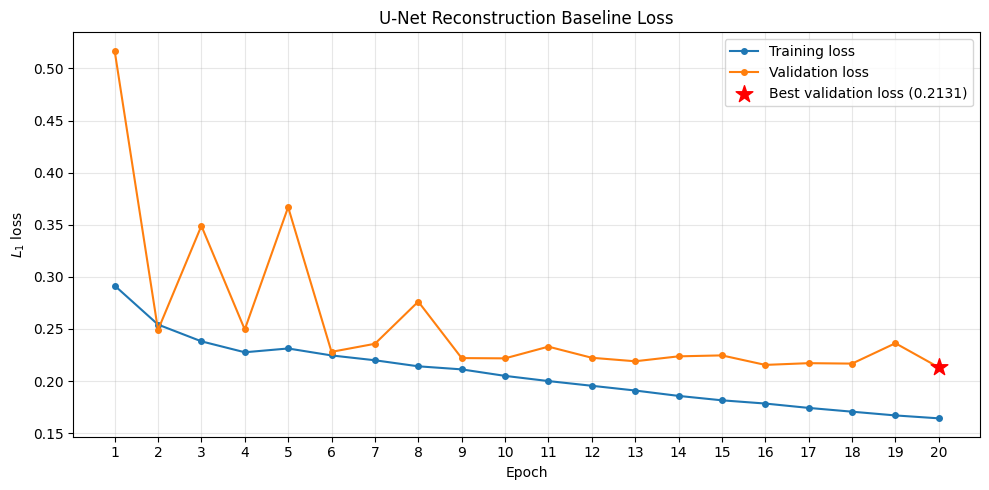

In [40]:
# Plot Full Training History

if history is not None and history.get("train_loss"):
    train_losses = history["train_loss"]
    validation_losses = history["validation_loss"]
    epochs = range(1, len(train_losses) + 1)

    best_epoch = (
        min(
            range(len(validation_losses)),
            key=validation_losses.__getitem__,
        )
        + 1
    )
    best_loss = validation_losses[best_epoch - 1]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        label="Training loss",
    )
    ax.plot(
        epochs,
        validation_losses,
        marker="o",
        markersize=4,
        label="Validation loss",
    )
    ax.scatter(
        best_epoch,
        best_loss,
        color="red",
        marker="*",
        s=160,
        zorder=3,
        label=f"Best validation loss ({best_loss:.4f})",
    )

    ax.set_title("U-Net Reconstruction Baseline Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(r"$L_1$ loss")
    ax.set_xticks(list(epochs))
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()

    fig.savefig(
        FIGURE_DIR / "unet_baseline_loss.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
else:
    print("Full training history is unavailable.")

### Observation

Training loss decreased monotonically across all 20 epochs, from 0.2916 to 0.1643. Validation loss fluctuated during the first eight epochs, ranging from 0.2250 to 0.5170, before stabilizing within a narrower range between 0.2131 and 0.2363. This early instability may be partly explained by batch-normalization running statistics that were still adapting, since validation in evaluation mode used the running statistics, whereas training used the current batch statistics.

The best validation loss of 0.2131 was reached at epoch 20. Between epochs 12 and 20, validation loss improved by less than 0.01, while training loss decreased by more than 0.03. This indicates diminishing improvement on unseen data and a gradually widening gap between the two curves. Therefore, 20 epochs provide a sufficient training budget for this baseline before comparison with the Pix2Pix model.

The mean epoch duration was 91.4 seconds, giving a total of 30.5 minutes for training and validation.

## Validation Predictions

The generator weights associated with the lowest validation loss are reloaded for qualitative inspection. A fixed set of validation edge maps is then passed through the model to examine what visual information the non-adversarial baseline can reconstruct using only the pixel-wise $L_1$ objective. The same examples will later be used for comparison with Pix2Pix.

In [41]:
# Load Best Reconstruction Generator

best_generator = None

if BEST_GENERATOR_PATH.is_file():
    best_generator_weights = torch.load(
        BEST_GENERATOR_PATH,
        map_location=DEVICE,
        weights_only=True,
    )

    best_generator = UNetGenerator().to(DEVICE)
    best_generator.load_state_dict(best_generator_weights)
    best_generator.eval()

    print(
        "Best generator loaded from: "
        f"{BEST_GENERATOR_PATH}"
    )
else:
    print(
        "Best generator weights were not found at: "
        f"{BEST_GENERATOR_PATH}"
    )

Best generator loaded from: /content/drive/MyDrive/Sketch2Furniture/checkpoints/unet_baseline/best_generator.pt


In [42]:
# Generate Validation Predictions

NUM_DISPLAY_PAIRS = 6

validation_dataset = validation_loader.dataset

display_indices = torch.linspace(
    0,
    len(validation_dataset) - 1,
    steps=NUM_DISPLAY_PAIRS,
).round().long().tolist()

display_samples = [
    validation_dataset[index]
    for index in display_indices
]

display_inputs = torch.stack(
    [sample["input"] for sample in display_samples]
).to(DEVICE)

display_targets = torch.stack(
    [sample["target"] for sample in display_samples]
)

display_pair_ids = [
    sample["pair_id"]
    for sample in display_samples
]

with torch.inference_mode():
    with torch.autocast(
        device_type=DEVICE.type,
        dtype=AMP_DTYPE,
        enabled=USE_AMP,
    ):
        display_predictions = best_generator(display_inputs)

display_inputs = display_inputs.float().cpu()
display_targets = display_targets.float().cpu()
display_predictions = display_predictions.float().cpu()

print(f"Display indices: {display_indices}")
print(f"Pair identifiers: {display_pair_ids}")
print(f"Prediction shape: {tuple(display_predictions.shape)}")
print(
    "Prediction range: "
    f"[{display_predictions.min():.3f}, "
    f"{display_predictions.max():.3f}]"
)

Display indices: [0, 341, 683, 1024, 1366, 1707]
Pair identifiers: ['pair_00005', 'pair_02860', 'pair_05659', 'pair_08577', 'pair_11498', 'pair_14334']
Prediction shape: (6, 3, 256, 256)
Prediction range: [-0.857, 1.000]


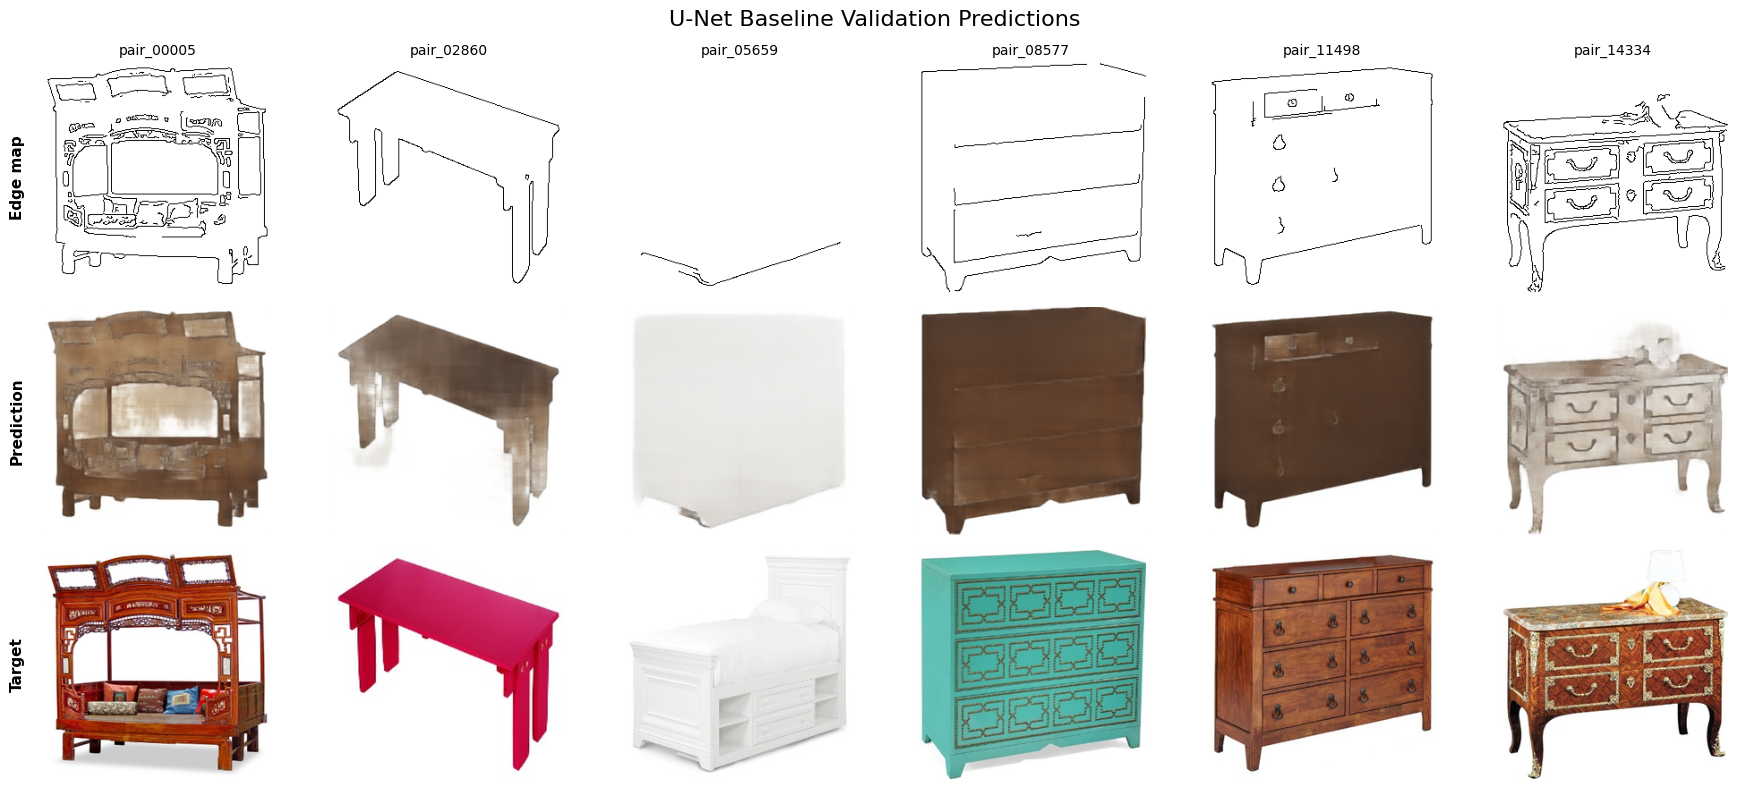

In [43]:
# Display Validation Predictions

display_rows = [
    ("Edge map", display_inputs),
    ("Prediction", display_predictions),
    ("Target", display_targets),
]

fig, axes = plt.subplots(
    nrows=len(display_rows),
    ncols=NUM_DISPLAY_PAIRS,
    figsize=(18, 8),
    squeeze=False,
)

for column_index, pair_id in enumerate(display_pair_ids):
    axes[0, column_index].set_title(
        pair_id,
        fontsize=10,
    )

    for row_index, (row_label, images) in enumerate(display_rows):
        image = (
            denormalize(images[column_index])
            .permute(1, 2, 0)
            .numpy()
        )

        if image.shape[-1] == 1:
            axes[row_index, column_index].imshow(
                image.squeeze(-1),
                cmap="gray",
                vmin=0,
                vmax=1,
            )
        else:
            axes[row_index, column_index].imshow(image)

        axes[row_index, column_index].axis("off")

        if column_index == 0:
            axes[row_index, column_index].text(
                -0.08,
                0.5,
                row_label,
                transform=axes[row_index, column_index].transAxes,
                rotation=90,
                va="center",
                ha="right",
                fontsize=11,
                fontweight="bold",
            )

fig.suptitle(
    "U-Net Baseline Validation Predictions",
    fontsize=16,
)

plt.tight_layout()

fig.savefig(
    FIGURE_DIR / "unet_baseline_validation_predictions.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Observation

The U-Net baseline recovers the coarse silhouette and general spatial structure of most validation examples.

The predictions are consistently blurred and desaturated. Fine carvings, drawer boundaries, handles, surface textures, and decorative patterns are largely removed, while vivid red, magenta, and turquoise targets are frequently reconstructed using muted brown or beige tones. This behaviour is characteristic of a pixel-wise $L_1$ objective, which favours averaged outputs that reduce reconstruction error rather than sharp, perceptually realistic details.

These results establish a useful non-adversarial baseline. The later Pix2Pix comparison will show whether adversarial training improves edge sharpness, colour fidelity, texture, and preservation of fine furniture details.

## Initial Baseline Analysis

The non-adversarial U-Net provides a stable reference point for evaluating the contribution of adversarial training. Its best validation $L_1$ loss was 0.2131 at epoch 20, and the small improvement during the later epochs indicates diminishing gains from continuing the reconstruction-only training.

Qualitatively, the model learns the global relationship between furniture edges and image structure, but it does not reconstruct realistic fine detail or reliable colour. The blurred and desaturated predictions demonstrate an important limitation of optimizing only pixel-wise $L_1$ loss: uncertain visual features are averaged rather than reproduced sharply. The failure on the sparse edge map also shows that reconstruction quality depends strongly on how much structural information is retained by the input representation.

## Saving the Best Model and Training History

The training state was saved automatically at the end of every epoch. The latest checkpoint contains the generator, optimizer, gradient scaler, completed epoch, loss history, and best validation loss, allowing training to resume consistently after an interruption. The standalone generator weights were updated only when validation loss improved.

| Artifact | Contents |
|---|---|
| `latest_checkpoint.pt` | Complete resumable state and training history through epoch 20 |
| `best_generator.pt` | Generator weights from epoch 20, with the best validation $L_1$ loss of 0.2131 |
| `unet_baseline_loss.png` | Training and validation loss curves |
| `unet_baseline_validation_predictions.png` | Fixed validation prediction gallery |

These artifacts were successfully written to Google Drive during the executed training and visualization cells. Therefore, no additional saving operation is required.

## Conclusions and Next Steps

The non-adversarial U-Net established a reconstruction baseline for the furniture edge-to-image task. Its training remained stable across 20 epochs, reaching its best validation $L_1$ loss of 0.2131 at epoch 20. The validation predictions showed that the model can recover coarse furniture shape and spatial structure, but produces blurred, desaturated images with limited texture and fine detail.

This baseline provides two complementary reference points for Pix2Pix: validation $L_1$ loss measures pixel-level reconstruction accuracy, while the fixed prediction gallery supports qualitative comparison of sharpness, colour fidelity, texture, and detail preservation.

The next notebook will introduce the Pix2Pix adversarial training pipeline by combining the U-Net generator with a PatchGAN discriminator. The same validation examples will be reused to provide a direct and consistent comparison between reconstruction-only and adversarial training.